![alternatvie text](https://www.doc.zuv.fau.de//M/FAU-Logo/01_FAU_Kernmarke/Web/FAU_Kernmarke_Q_RGB_blue.svg)


# Assignment 1: Small Scale Data (Classification)

In this assignment basic functionalities of [PyTorch](https://docs.pytorch.org/docs/stable/index.html) will be explored for small datasets. The goal is to work on how to load images, pre-process the images and perform data augmentation. Finally, a deep neural network will be trained to perform image classification.

Note that all scripts should be self-contained and executed on *any* machine that has the required libraries installed. Moreover, you'll need to install PyTorch prior to starting this tutorial. This should be done using [Conda](https://anaconda.org/anaconda/conda). For more info. check [Install PyTorch](https://www.scaler.com/topics/pytorch/install-pytorch/) [Install PyTorch on Jupyter](https://medium.com/@kajaani1705/a-step-by-step-guide-to-using-pytorch-with-vscode-in-jupyter-notebook-f09c427f84e4)

The solutions of the assignment can be delivered as Python Notebooks or `.py` files.

## Data loading 

In this task, the data will be loaded in two different ways. At first, the `torchvision.datasets` subclasses will be used to load a dataset. Second, you will write your own dataset loader that performs the same task. In the second case, the data and labels will be loaded from the hard-drive. Alternatively, they can be loaded from the RAM memory. Both solutions are acceptable. Only the train set is required. The datasets are [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) and [MNIST](https://git-disl.github.io/GTDLBench/datasets/mnist_datasets/). Finally, the data samples and labels will be visualized. 

*Task Output*: It will be **two** different data loaders for MNIST and Fashion-MNIST. To demonstrate the data loading, the images and the corresponding labels should be vizualized. For the **visualization of the image and label**, you may use any library that you wish (e.g. [matplotlib](http://matplotlib.org/)).

*Important*: The scripts should be **self-contained**. This means that the custom dataloader should: 1. check whether the dataset is locally stored and 2. download it from the web if it not locally stored.

Tip: If it is not clear what the train / test set is when loading the data, you may check on the web-page of the dataset or on the related publication.

### a) Built-in Torch Dataloader

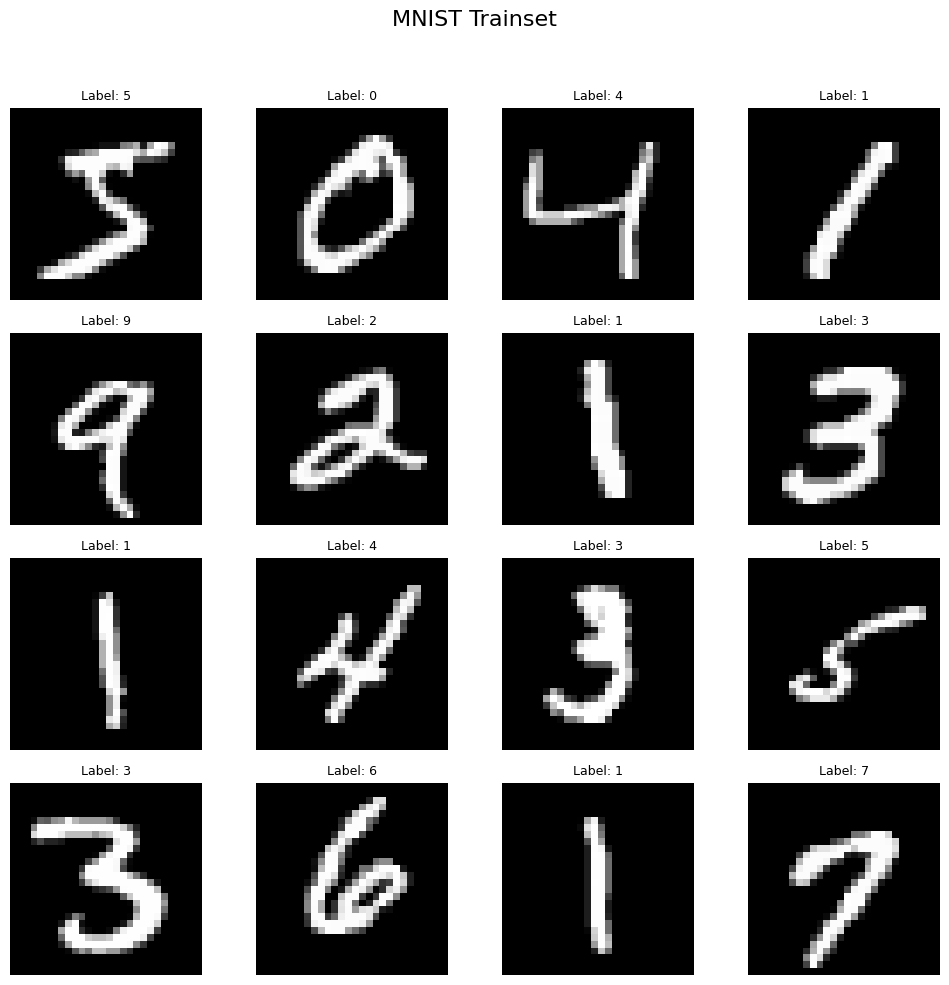

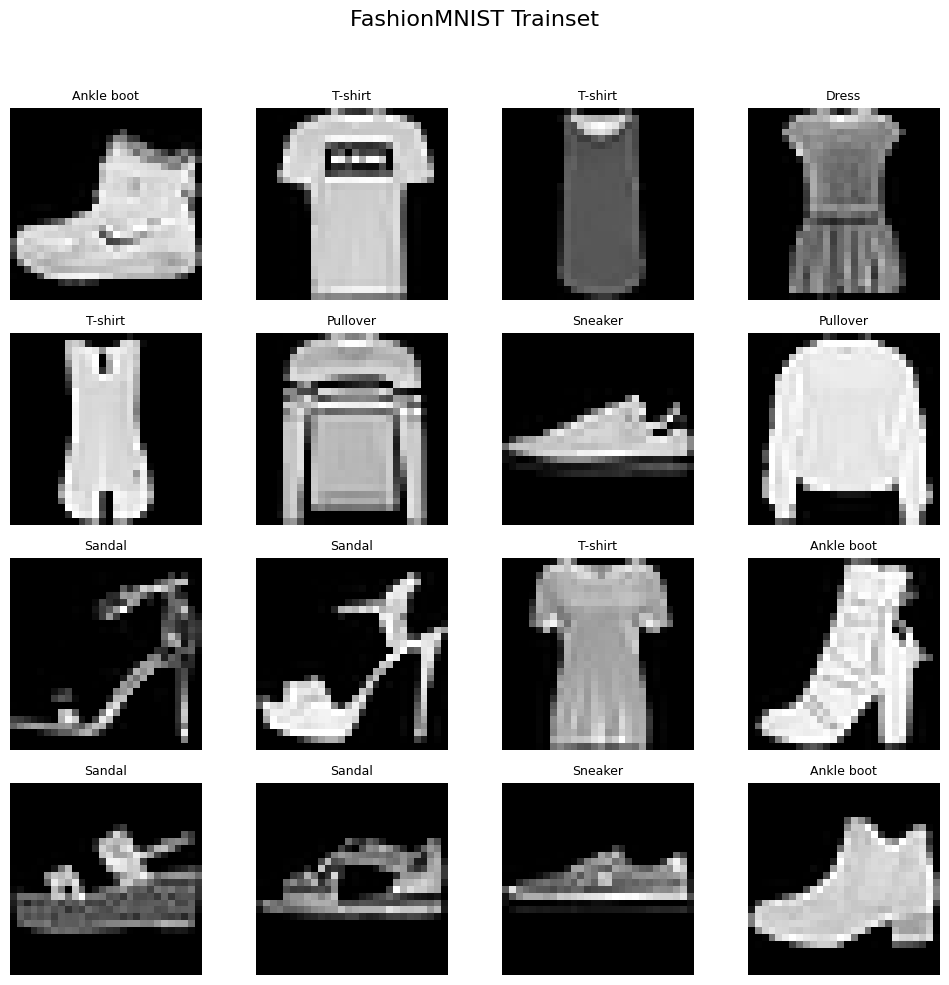

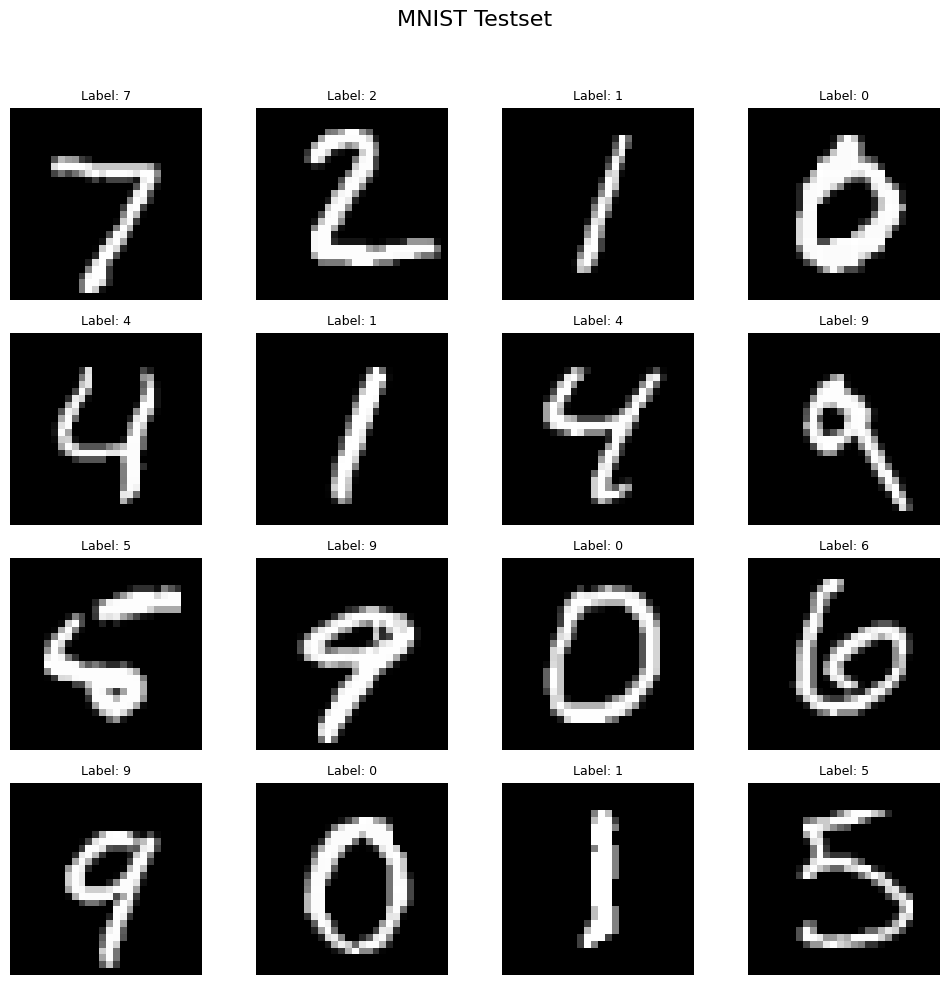

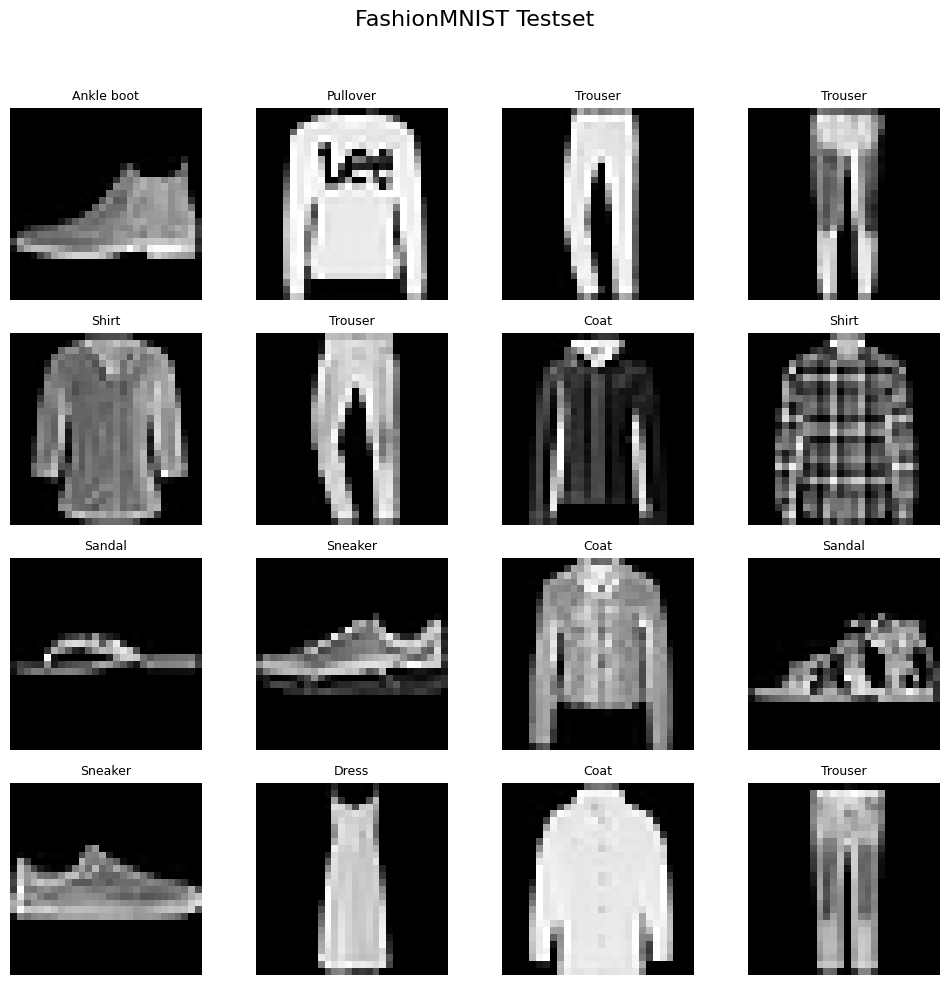

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import gzip
import struct
from pathlib import Path
import numpy as np

# TODO:
# 1. Load MNIST train/test
# Define a transform to convert images to tensors
transform = transforms.ToTensor()

# Load the training dataset
train_dataset_mnist = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset_mnist = datasets.MNIST(root='data', train=False, download=True, transform=transform)
                               
# 2. Load FashionMNIST train/test
# Load the training dataset
train_dataset_fashion_mnist = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_dataset_fashion_mnist = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)

fashion_classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
    
# Dataloader MNIST
ROOT = "./data"

def show_dataset_grid(dataset, title, class_names=None, rows=4, cols=4):
    fig, axs = plt.subplots(rows, cols, figsize=(10, 10))
    fig.suptitle(title, fontsize=16)

    for i in range(rows):
        for j in range(cols):
            image, label = dataset[i * cols + j]
            image_numpy = image.numpy().squeeze()

            axs[i, j].imshow(image_numpy, cmap="gray")
            axs[i, j].axis("off")

            if class_names is not None:
                axs[i, j].set_title(class_names[label], fontsize=9)
            else:
                axs[i, j].set_title(f"Label: {label}", fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_dataset_grid(train_dataset_mnist, "MNIST Trainset", class_names=None)
show_dataset_grid(train_dataset_fashion_mnist, "FashionMNIST Trainset", class_names=fashion_classes)

show_dataset_grid(test_dataset_mnist, "MNIST Testset", class_names=None)
show_dataset_grid(test_dataset_fashion_mnist, "FashionMNIST Testset", class_names=fashion_classes)

### b) Customized Dataset

In this part, implement your own `torch.utils.data.Dataset` class.\
\
Your class should:
1. load images and labels,
2. implement `__len__`,
3. implement `__getitem__`,
4. implement `_download_dataset`
4. return one image-label pair at a time.

 To this end, you'll have to implement a function which downloads the datasets if it can not be found locally. You may use this download link 'https://drive.google.com/file/d/11ZiNnV3YtpZ7d9afHZg0rtDRrmhha-1E/view'.
 Also, you can rely on this documentation to handle [Gzip](https://docs.python.org/3/library/gzip.html#:~:text=To%20open%20a%20compressed%20file,and%20produces%20the%20most%20compression.) file format i.e. unzip file.\
 Additional information on CustomDataset class can be obtained here [PyTorch Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html).

MNIST: Dataset missing, starting download...
Downloaded: train-images-idx3-ubyte.gz
Downloaded: train-labels-idx1-ubyte.gz
Downloaded: t10k-images-idx3-ubyte.gz
Downloaded: t10k-labels-idx1-ubyte.gz
MNIST: Download complete.
MNIST: Dataset locally available.
FashionMNIST: Dataset missing, starting download...
Downloaded: train-images-idx3-ubyte.gz
Downloaded: train-labels-idx1-ubyte.gz
Downloaded: t10k-images-idx3-ubyte.gz
Downloaded: t10k-labels-idx1-ubyte.gz
FashionMNIST: Download complete.
FashionMNIST: Dataset locally available.
60000
60000


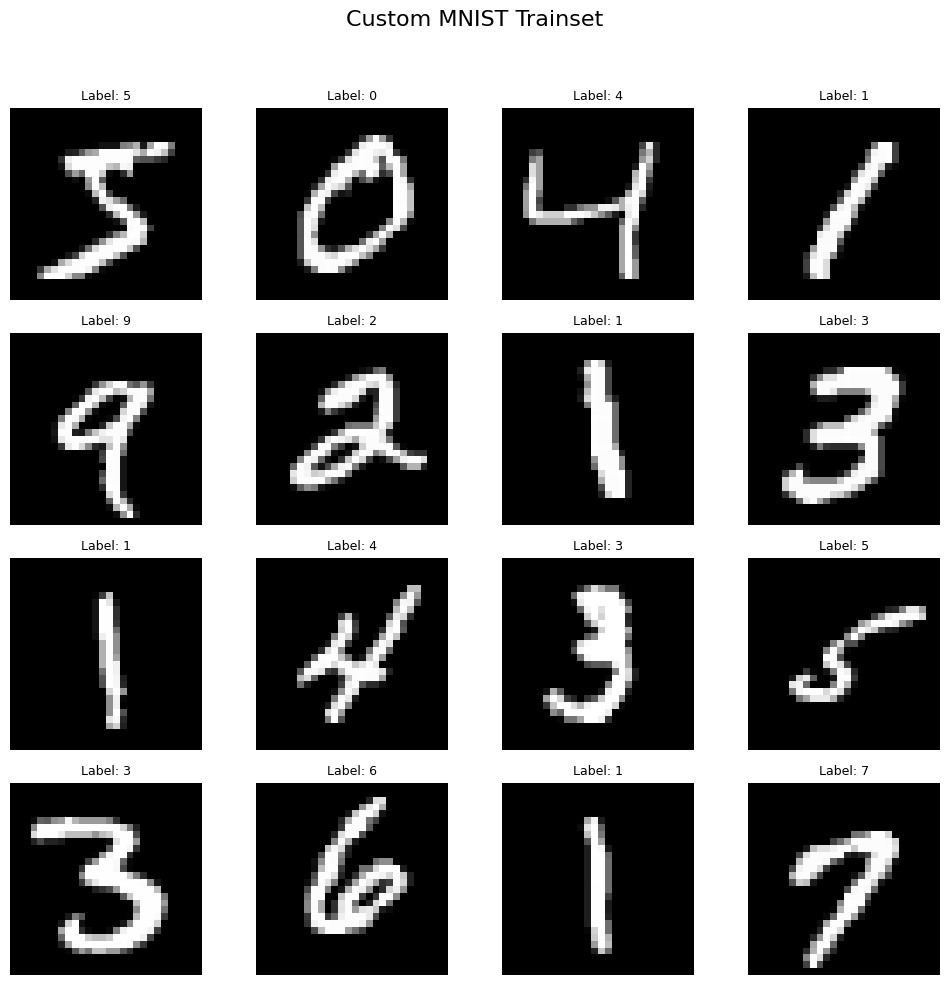

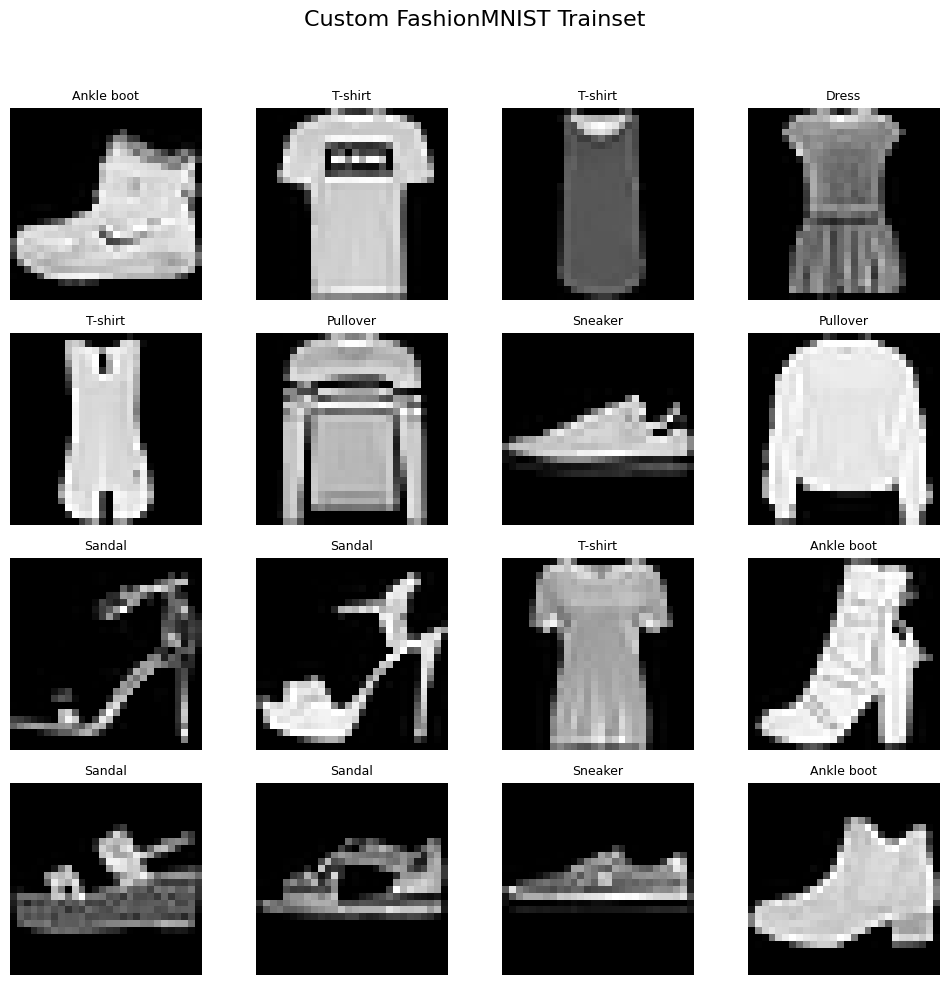

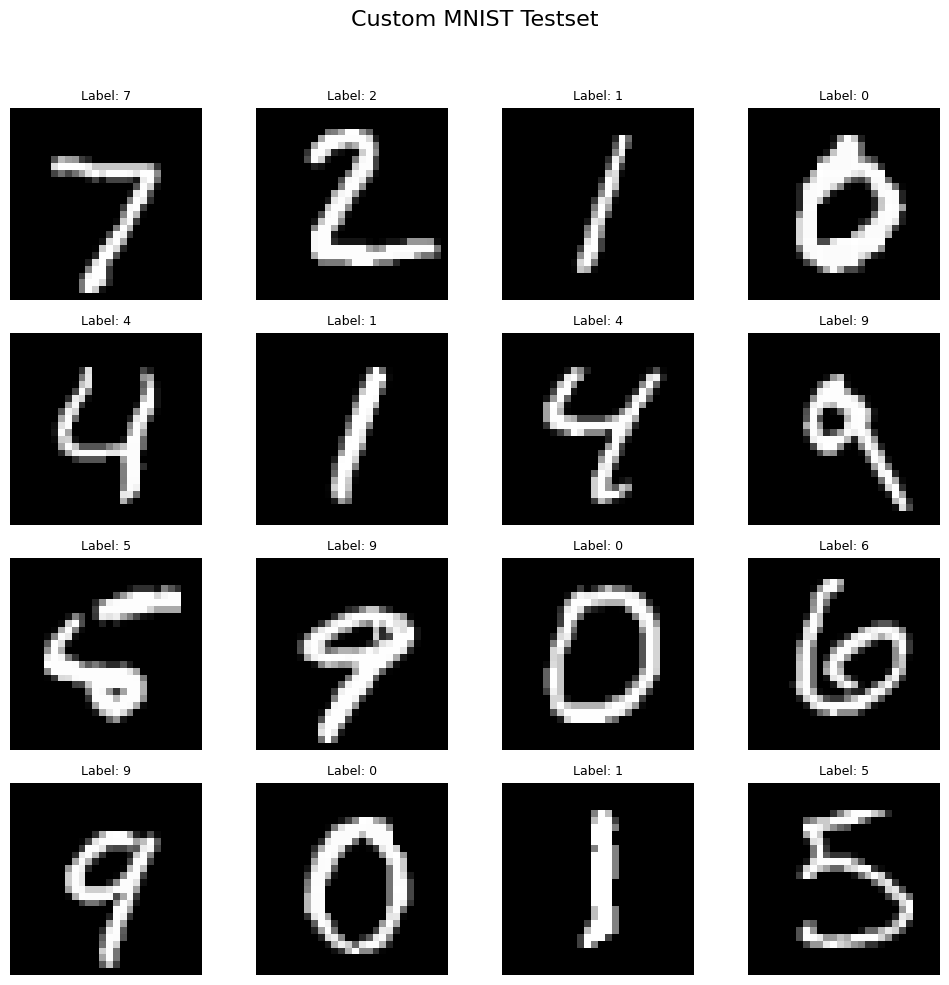

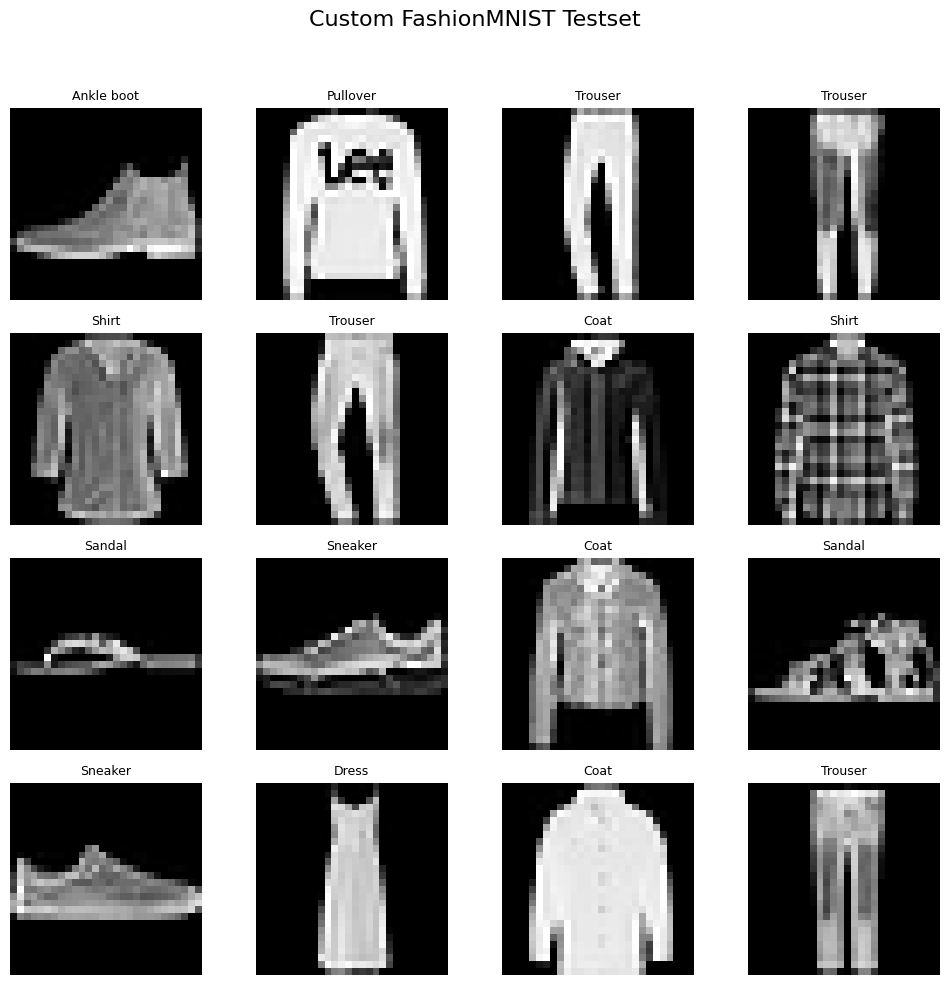

In [9]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
import urllib.request

class CustomClassification(Dataset):
    def __init__(self, root, dataset_name, auto_download=True, train=True):
        self.root = Path(root)
        self.dataset_name = dataset_name

        self.raw_dir = self.root / dataset_name / "raw"
        self.images_path = self.raw_dir / "train-images-idx3-ubyte.gz"
        self.labels_path = self.raw_dir / "train-labels-idx1-ubyte.gz"

        self.images = None
        self.labels = None

        self.train = train

        if self.train:
            self.images_path = self.raw_dir / "train-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "train-labels-idx1-ubyte.gz"
        else:
            self.images_path = self.raw_dir / "t10k-images-idx3-ubyte.gz"
            self.labels_path = self.raw_dir / "t10k-labels-idx1-ubyte.gz"

        self._download_dataset(auto_download=auto_download)

    def _download_dataset(self, auto_download=True):
        if auto_download:
            self._ensure_dataset_exists()

        if not self.images_path.exists():
            raise FileNotFoundError(f"Missing: {self.images_path}")

        if not self.labels_path.exists():
            raise FileNotFoundError(f"Missing: {self.labels_path}")

        self.images = self._read_images(self.images_path)
        self.labels = self._read_labels(self.labels_path)

        if len(self.images) != len(self.labels):
            raise ValueError("Number of Images and Labels don't match.")
        
    def _download_file(self, url, destination):
        destination.parent.mkdir(parents=True, exist_ok=True)

        try:
            urllib.request.urlretrieve(url, destination)
            print(f"Downloaded: {destination.name}")
        except Exception as e:
            if destination.exists():
                destination.unlink()
            raise RuntimeError(
                f"Download failed for {url}: {e}"
            )
        
    def _ensure_dataset_exists(self):
        self.raw_dir.mkdir(parents=True, exist_ok=True)

        dataset_urls = {
            "MNIST": {
                "train-images-idx3-ubyte.gz": (
                    "https://ossci-datasets.s3.amazonaws.com/mnist/"
                    "train-images-idx3-ubyte.gz"
                ),
                "train-labels-idx1-ubyte.gz": (
                    "https://ossci-datasets.s3.amazonaws.com/mnist/"
                    "train-labels-idx1-ubyte.gz"
                ),
                "t10k-images-idx3-ubyte.gz": (
                    "https://ossci-datasets.s3.amazonaws.com/mnist/"
                    "t10k-images-idx3-ubyte.gz"
                ),
                "t10k-labels-idx1-ubyte.gz": (
                    "https://ossci-datasets.s3.amazonaws.com/mnist/"
                    "t10k-labels-idx1-ubyte.gz"
                ),
            },
            "FashionMNIST": {
                "train-images-idx3-ubyte.gz": (
                    "https://raw.githubusercontent.com/"
                    "zalandoresearch/fashion-mnist/master/data/fashion/"
                    "train-images-idx3-ubyte.gz"
                ),
                "train-labels-idx1-ubyte.gz": (
                    "https://raw.githubusercontent.com/"
                    "zalandoresearch/fashion-mnist/master/data/fashion/"
                    "train-labels-idx1-ubyte.gz"
                ),
                "t10k-images-idx3-ubyte.gz": (
                    "https://raw.githubusercontent.com/"
                    "zalandoresearch/fashion-mnist/master/data/fashion/"
                    "t10k-images-idx3-ubyte.gz"
                ),
                "t10k-labels-idx1-ubyte.gz": (
                    "https://raw.githubusercontent.com/"
                    "zalandoresearch/fashion-mnist/master/data/fashion/"
                    "t10k-labels-idx1-ubyte.gz"
                ),
            },
        }

        if self.dataset_name not in dataset_urls:
            raise ValueError(f"Unknown Dataset: {self.dataset_name}")

        required_files = dataset_urls[self.dataset_name]

        all_exist = all(
            (self.raw_dir / filename).exists()
            for filename in required_files
        )

        if all_exist:
            print(f"{self.dataset_name}: Dataset locally available.")
            return

        print(f"{self.dataset_name}: Dataset missing, starting download...")

        for filename, url in required_files.items():
            target_path = self.raw_dir / filename

            if target_path.exists():
                print(f"Already exists: {filename}")
                continue

            print(f"Downloading {filename} ...")
            self._download_file(url, target_path)

        print(f"{self.dataset_name}: Download complete.")
        
    
    def _read_images(self, path):
        with gzip.open(path, "rb") as f: # Read Bytes!
            magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16)) # Unpack first 16 Bytes, because Header of MNIST Images consists of 4 returns à 4 Bytes
                                                        # >: Big Endian, I: unsigned int = >IIII: read 4 unsigned ints in Big Endian Format
            if magic != 2051: # First check: Is the Data an Image? If not it's not an Image or corrupted or smth else
                raise ValueError(
                    f"Invalid magic number for Images: {magic}"
                )

            data = np.frombuffer(f.read(), dtype=np.uint8) # Read remaining data as NumPy Array with uint8 format (values from 0 to 255)
            data = data.reshape(num_images, rows, cols) # Reshape Data as 3D Tensor (60000, 28, 28)

        return data

    def _read_labels(self, path):
        with gzip.open(path, "rb") as f: # Read Bytes!
            magic, num_labels = struct.unpack(">II", f.read(8)) # Unpack first 8 Bytes, because Header of MNIST Labels consists of 2 returns à 4 Bytes
                                            # >: Big Endian, I: unsigned int = >II: read 2 unsigned ints in Big Endian Format
            if magic != 2049: # First check: Is the Data a Label? If not it's not an Label or corrupted or smth else
                raise ValueError(
                    f"Invalid magic number for Labels: {magic}"
                )

            labels = np.frombuffer(f.read(), dtype=np.uint8)

        if len(labels) != num_labels:
            raise ValueError("Number of Labels don't match.")

        return labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self,idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0

        return image, label
    

ROOT = "./data"

# Dataloader MNIST
mnist_train_custom = CustomClassification(
    root="./data",
    dataset_name="MNIST",
    train=True,
)

mnist_test_custom = CustomClassification(
    root="./data",
    dataset_name="MNIST",
    train=False,
)

# Dataloader FashionMNIST
fashion_train_custom = CustomClassification(
    root="./data",
    dataset_name="FashionMNIST",
    train=True,
)

fashion_test_custom = CustomClassification(
    root="./data",
    dataset_name="FashionMNIST",
    train=False,
)

print(len(mnist_train_custom))
print(len(fashion_train_custom))

show_dataset_grid(mnist_train_custom, "Custom MNIST Trainset", class_names=None)
show_dataset_grid(fashion_train_custom, "Custom FashionMNIST Trainset", class_names=fashion_classes)

show_dataset_grid(mnist_test_custom, "Custom MNIST Testset", class_names=None)
show_dataset_grid(fashion_test_custom, "Custom FashionMNIST Testset", class_names=fashion_classes)

## 2. Model training 

In this task, the MNIST and [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset will be employed for learning a classifier. The classifier will be a convolutional neural network. You are free to decide for the network architecture. \
Your network must include:
- at least **2 convolution layers**
- at least **1 linear layer**
- **ReLU** activations
- **CrossEntropyLoss**

Training will take place based on the train set of the dataset, also you should use part of the train set as validation and save the model with the best validation score. The test set will be used only for evaluation. Finally, the custom data-loader which has been implemented earlier will be employed here. Since there is train and test set, the data loader might need adaptation.\
\
Parameter learning: The computation of the gradients and the optimization will be based on Pytorch (`torch.optim`).

Task Output: The output will be two **figures**, where in the first figure the x - axis represents the epochs and the y-axis represents the error. The plot of the train and test set will be drawn. The second figure will show the accuracy per epoch for the train and test set. Finally, the optimization parameters (optimizer and hyper-parameters) will be reported too.


Starting Experiment with MNIST
MNIST: Dataset locally available.
MNIST: Dataset locally available.
Device: cuda
Epoch [1/10] | Train Loss: 0.2011, Train Acc: 0.9396 | Val Loss: 0.0662, Val Acc: 0.9800 | Test Loss: 0.0576, Test Acc: 0.9814
Epoch [2/10] | Train Loss: 0.0553, Train Acc: 0.9827 | Val Loss: 0.0531, Val Acc: 0.9835 | Test Loss: 0.0428, Test Acc: 0.9862
Epoch [3/10] | Train Loss: 0.0389, Train Acc: 0.9880 | Val Loss: 0.0461, Val Acc: 0.9872 | Test Loss: 0.0387, Test Acc: 0.9868
Epoch [4/10] | Train Loss: 0.0307, Train Acc: 0.9904 | Val Loss: 0.0397, Val Acc: 0.9882 | Test Loss: 0.0303, Test Acc: 0.9898
Epoch [5/10] | Train Loss: 0.0262, Train Acc: 0.9919 | Val Loss: 0.0453, Val Acc: 0.9867 | Test Loss: 0.0364, Test Acc: 0.9883
Epoch [6/10] | Train Loss: 0.0217, Train Acc: 0.9932 | Val Loss: 0.0502, Val Acc: 0.9857 | Test Loss: 0.0416, Test Acc: 0.9870
Epoch [7/10] | Train Loss: 0.0182, Train Acc: 0.9944 | Val Loss: 0.0421, Val Acc: 0.9880 | Test Loss: 0.0321, Test Acc: 0.988

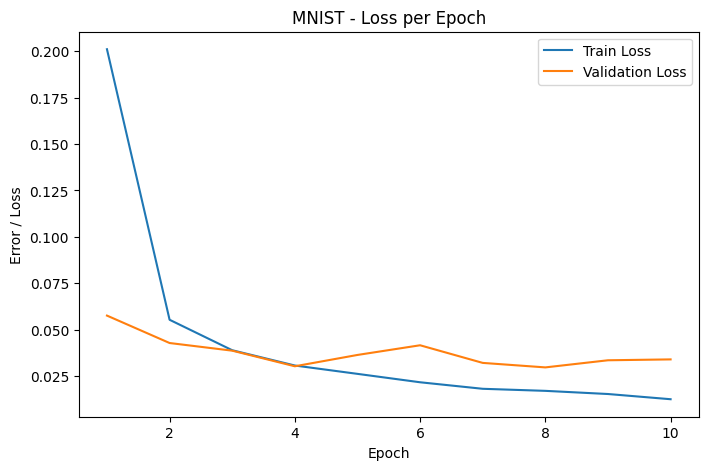

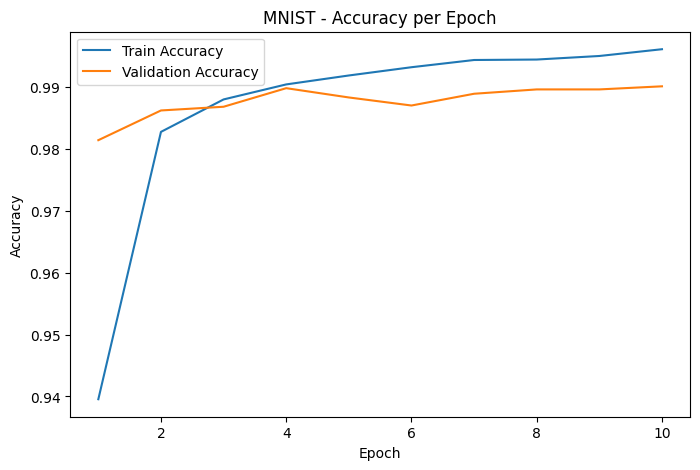

MNIST Hyperparameter:
dataset_name: MNIST
batch_size: 64
epochs: 10
lr: 0.001
weight_decay: 0.0001
val_ratio: 0.1
seed: 67
MNIST Final Test Accuracy: 0.9896

Starting Experiment with FashionMNIST
FashionMNIST: Dataset locally available.
FashionMNIST: Dataset locally available.
Device: cuda
Epoch [1/10] | Train Loss: 0.4771, Train Acc: 0.8283 | Val Loss: 0.3542, Val Acc: 0.8747 | Test Loss: 0.3718, Test Acc: 0.8647
Epoch [2/10] | Train Loss: 0.3046, Train Acc: 0.8895 | Val Loss: 0.3074, Val Acc: 0.8927 | Test Loss: 0.3255, Test Acc: 0.8841
Epoch [3/10] | Train Loss: 0.2589, Train Acc: 0.9052 | Val Loss: 0.2612, Val Acc: 0.9102 | Test Loss: 0.2712, Test Acc: 0.9024
Epoch [4/10] | Train Loss: 0.2315, Train Acc: 0.9151 | Val Loss: 0.2503, Val Acc: 0.9127 | Test Loss: 0.2595, Test Acc: 0.9057
Epoch [5/10] | Train Loss: 0.2110, Train Acc: 0.9216 | Val Loss: 0.2334, Val Acc: 0.9153 | Test Loss: 0.2461, Test Acc: 0.9115
Epoch [6/10] | Train Loss: 0.1922, Train Acc: 0.9279 | Val Loss: 0.2362, V

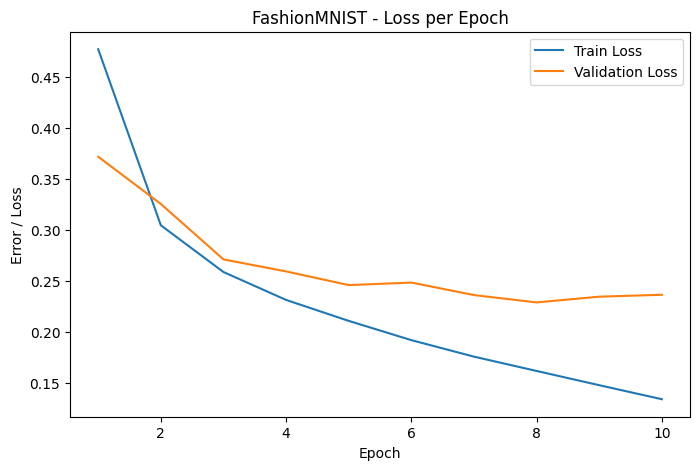

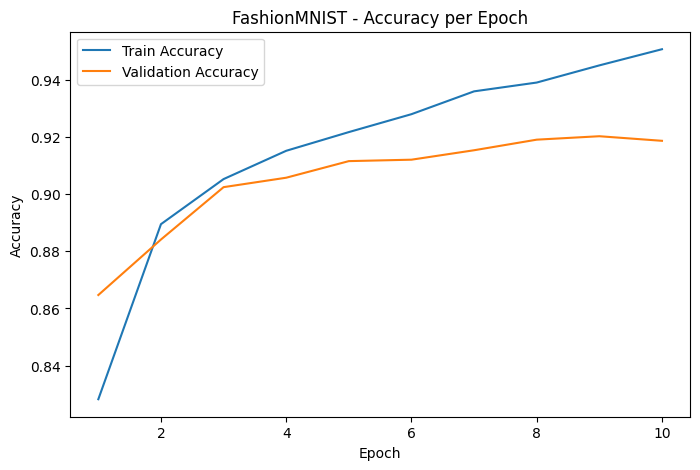

FashionMNIST Hyperparameter:
dataset_name: FashionMNIST
batch_size: 64
epochs: 10
lr: 0.001
weight_decay: 0.0001
val_ratio: 0.1
seed: 67
FashionMNIST Final Test Accuracy: 0.9202


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# Implement your network

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1,
        )
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128) # = Tensor size input, 128 output
        self.fc2 = nn.Linear(128, num_classes) # 128 input, num_classes output

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))   # 14x14 -> 7x7

        x = torch.flatten(x, start_dim=1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Train
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Evaluate
@torch.no_grad() #No calculation or saving of gradients for following function
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Run Experiment
def run_experiment(
    dataset_name,
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    val_ratio=0.1,
    seed=67,
):
    print(f"\nStarting Experiment with {dataset_name}")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    full_train_dataset = CustomClassification(
        root=root,
        dataset_name=dataset_name,
        train=True,
        auto_download=True,
    )

    test_dataset = CustomClassification(
        root=root,
        dataset_name=dataset_name,
        train=False,
        auto_download=True,
    )

    val_size = int(len(full_train_dataset) * val_ratio)
    train_size = len(full_train_dataset) - val_size

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=generator,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    model = SimpleCNN(num_classes=10).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": [],
    }

    best_val_acc = 0.0
    model_path = f"best_{dataset_name.lower()}.pth"

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["test_loss"].append(test_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

    model.load_state_dict(torch.load(model_path, map_location=device))

    final_test_loss, final_test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    config = {
        "dataset_name": dataset_name,
        "batch_size": batch_size,
        "epochs": epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "val_ratio": val_ratio,
        "seed": seed,
    }

    results = {
        "best_val_acc": best_val_acc,
        "final_test_loss": final_test_loss,
        "final_test_acc": final_test_acc,
    }

    return model, history, config, results


def plot_history(history, dataset_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Figure 1: Loss / Error
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Error / Loss")
    plt.title(f"{dataset_name} - Loss per Epoch")
    plt.legend()
    plt.grid(False)
    plt.show()

    # Figure 2: Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{dataset_name} - Accuracy per Epoch")
    plt.legend()
    plt.grid(False)
    plt.show()


mnist_model, mnist_history, mnist_config, mnist_results = run_experiment(
    dataset_name="MNIST",
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

plot_history(mnist_history, "MNIST")

print("MNIST Hyperparameter:")
for key, value in mnist_config.items():
    print(f"{key}: {value}")

print(f"MNIST Final Test Accuracy: {mnist_results['final_test_acc']:.4f}")



fashion_model, fashion_history, fashion_config, fashion_results = run_experiment(
    dataset_name="FashionMNIST",
    root="./data",
    batch_size=64,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

plot_history(fashion_history, "FashionMNIST")

print("FashionMNIST Hyperparameter:")
for key, value in fashion_config.items():
    print(f"{key}: {value}")

print(
    f"FashionMNIST Final Test Accuracy: "
    f"{fashion_results['final_test_acc']:.4f}"
)


## 3. Data Augmentation


The datasets [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) and [MNIST](http://yann.lecun.com/exdb/mnist/) will be the testbed to investigate the impact of data augmentation. The source code from the last assignment can be used for data loading and model training. The network architecture can be the same from the last assignment as well. The data loading and augmentation can be done using the modules `torch.utils.data` and `torchvision`. Moreover, the dataset can be loaded from PyTorch class from each dataset.
 
*Task Output*: The required augmentation for this task is random affine with degree set to 20, translate (0.1,0.1) and scale (0.9,1.1). Moreover, color jitter should be applied on top with brightness set to 0.2 and also contrast to 0.2. At first, a model without augmentation should be trained. The performance on the test set will be the output of the task. Second, a model with data augmentation should be trained. The new performance on test will be now reported and compared to the accuracy without data augmentation.

*Important*: The scripts should be **self-contained**. The data augmentation should be dynamically implemented, i.e it is applied when the data from the mini-batch is loaded.

MNIST: Dataset locally available.
MNIST: Dataset locally available.
MNIST: Dataset locally available.
FashionMNIST: Dataset locally available.
FashionMNIST: Dataset locally available.
FashionMNIST: Dataset locally available.

Starting MNIST Plain
Device: cuda
Epoch [1/10] | Train Loss: 0.2012, Train Acc: 0.9385 | Val Loss: 0.0699, Val Acc: 0.9817 | Test Loss: 0.0572, Test Acc: 0.9814
Epoch [2/10] | Train Loss: 0.0564, Train Acc: 0.9826 | Val Loss: 0.0618, Val Acc: 0.9820 | Test Loss: 0.0505, Test Acc: 0.9829
Epoch [3/10] | Train Loss: 0.0391, Train Acc: 0.9879 | Val Loss: 0.0544, Val Acc: 0.9823 | Test Loss: 0.0410, Test Acc: 0.9859
Epoch [4/10] | Train Loss: 0.0333, Train Acc: 0.9892 | Val Loss: 0.0415, Val Acc: 0.9867 | Test Loss: 0.0308, Test Acc: 0.9897
Epoch [5/10] | Train Loss: 0.0265, Train Acc: 0.9915 | Val Loss: 0.0404, Val Acc: 0.9862 | Test Loss: 0.0320, Test Acc: 0.9896
Epoch [6/10] | Train Loss: 0.0204, Train Acc: 0.9934 | Val Loss: 0.0506, Val Acc: 0.9850 | Test Loss: 0.0

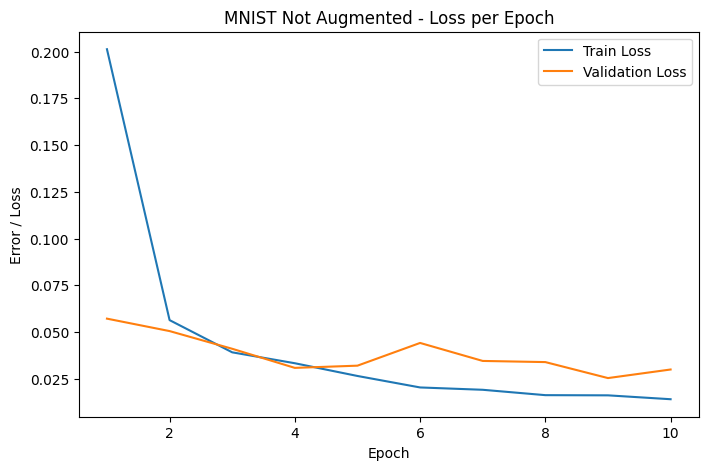

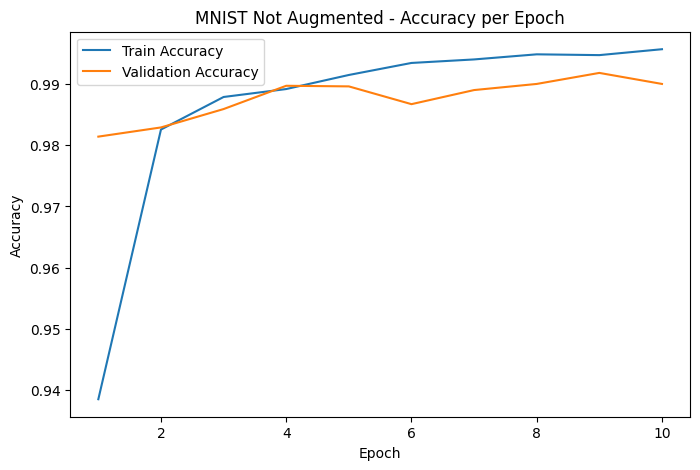

MNIST Plain Hyperparameter:
epochs: 10
lr: 0.001
weight_decay: 0.0001
model_path: best_mnist_plain.pth
seed: 67
experiment_name: MNIST Plain


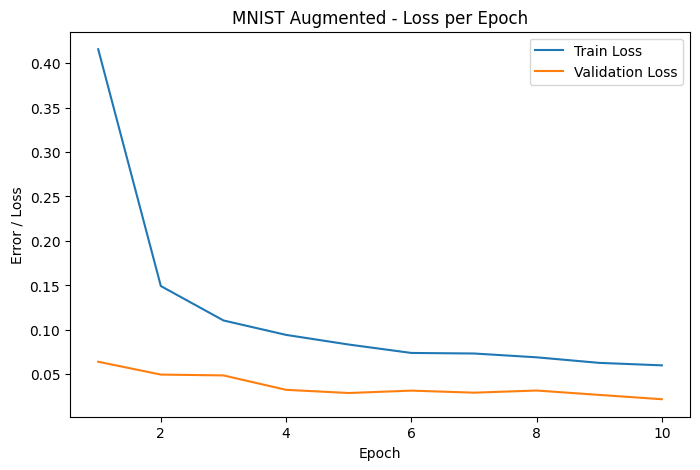

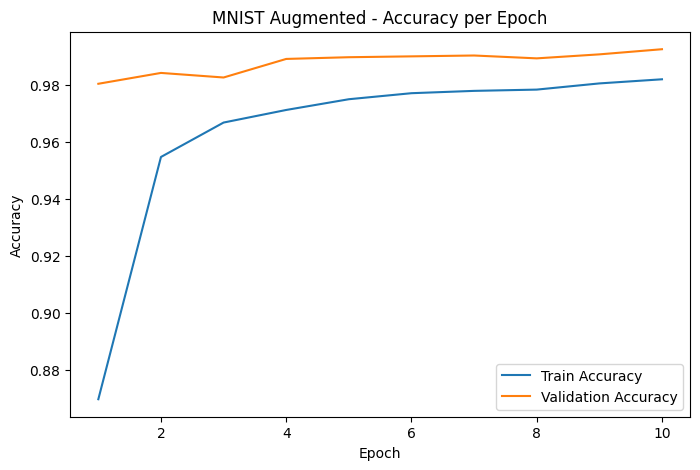

MNIST Augmented Hyperparameter:
epochs: 10
lr: 0.001
weight_decay: 0.0001
model_path: best_mnist_aug.pth
seed: 67
experiment_name: MNIST Augmented


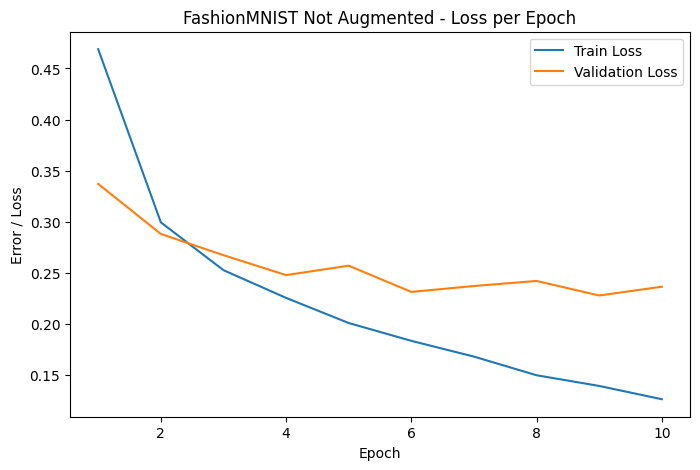

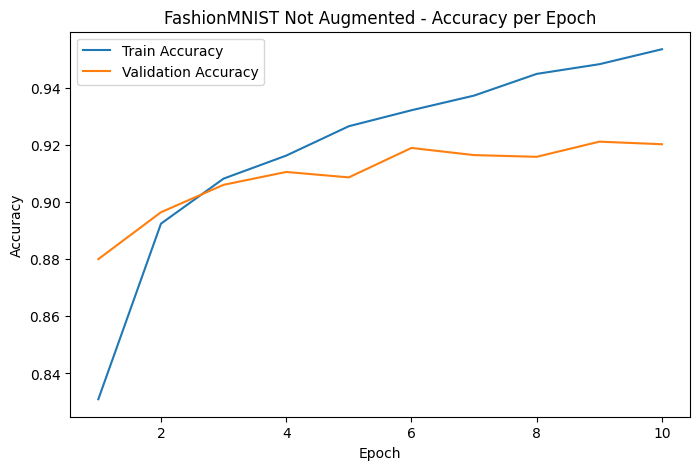

FashionMNIST Hyperparameter:
epochs: 10
lr: 0.001
weight_decay: 0.0001
model_path: best_fashionmnist_plain.pth
seed: 67
experiment_name: FashionMNIST Plain


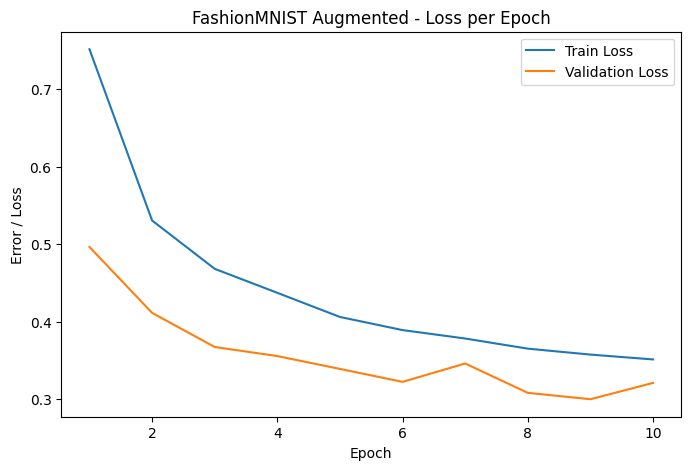

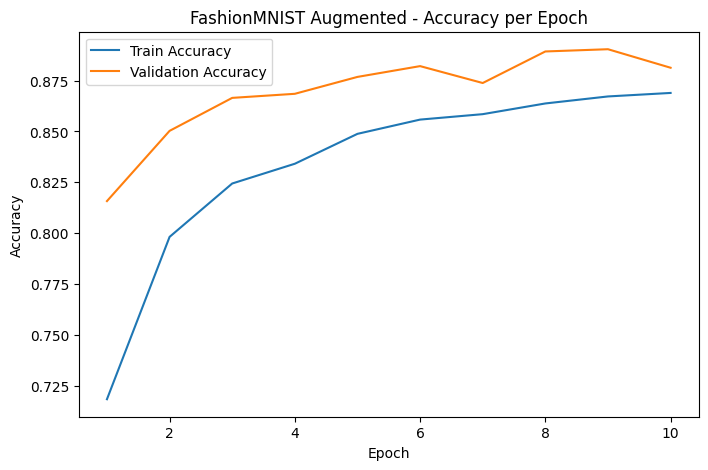

FashionMNIST Hyperparameter:
epochs: 10
lr: 0.001
weight_decay: 0.0001
model_path: best_fashionmnist_aug.pth
seed: 67
experiment_name: FashionMNIST Augmented

--- Final Comparison: Test accuracy ---
MNIST without Augmentation: 0.9918
MNIST with Augmentation: 0.9924
FashionMNIST without Augmentation: 0.9211
FashionMNIST with Augmentation: 0.8893


In [ ]:
import gzip
import struct
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms


# ---------------------- Custom Classification Training ----------------------

class CustomClassificationTraining(CustomClassification):
    def __init__(
        self,
        root,
        dataset_name,
        train=True,
        auto_download=True,
        transform=None,
    ):
        super().__init__(
            root=root,
            dataset_name=dataset_name,
            auto_download=auto_download,
            train=train,
        )
        self.transform = transform

    def __getitem__(self, idx):
        image, label = super().__getitem__(idx)

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ---------------------- Data Augmentation ----------------------

train_transform_aug = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),
])

# ---------------------- run_experiment updated ----------------------

def run_experiment3(
    train_loader,
    val_loader,
    test_loader,
    model,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_model.pth",
    seed=67,
    experiment_name="Experiment",
):
    print(f"\nStarting {experiment_name}")

    # Reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Model, Loss, Optimizer
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    # History
    history = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": [],
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device,
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            device,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["test_loss"].append(test_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
        )

    # Best model reload
    model.load_state_dict(torch.load(model_path, map_location=device))

    final_test_loss, final_test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device,
    )

    config = {
        "epochs": epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "model_path": model_path,
        "seed": seed,
        "experiment_name": experiment_name,
    }

    results = {
        "best_val_acc": best_val_acc,
        "final_test_loss": final_test_loss,
        "final_test_acc": final_test_acc,
    }

    return model, history, config, results

# ---------------------- Reproducibility ----------------------

seed = 67
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


# ---------------------- MNIST Datasets ----------------------

mnist_train_plain_full = CustomClassificationTraining(
    root="./data",
    dataset_name="MNIST",
    train=True,
    transform=None,
)

mnist_train_aug_full = CustomClassificationTraining(
    root="./data",
    dataset_name="MNIST",
    train=True,
    transform=train_transform_aug,
)

mnist_test = CustomClassificationTraining(
    root="./data",
    dataset_name="MNIST",
    train=False,
    transform=None,
)


# ---------------------- FashionMNIST Datasets ----------------------

fashion_train_plain_full = CustomClassificationTraining(
    root="./data",
    dataset_name="FashionMNIST",
    train=True,
    transform=None,
)

fashion_train_aug_full = CustomClassificationTraining(
    root="./data",
    dataset_name="FashionMNIST",
    train=True,
    transform=train_transform_aug,
)

fashion_test = CustomClassificationTraining(
    root="./data",
    dataset_name="FashionMNIST",
    train=False,
    transform=None,
)


# ---------------------- Fixed Indices ----------------------

generator = torch.Generator().manual_seed(seed)

val_ratio = 0.1
num_samples = len(mnist_train_plain_full)

val_size = int(num_samples * val_ratio)
train_size = num_samples - val_size

indices = torch.randperm(num_samples, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:]


# ---------------------- Fixed Splits: MNIST ----------------------

mnist_train_plain = Subset(mnist_train_plain_full, train_indices)
mnist_train_aug = Subset(mnist_train_aug_full, train_indices)
mnist_val = Subset(mnist_train_plain_full, val_indices)


# ---------------------- Fixed Splits: FashionMNIST ----------------------

fashion_train_plain = Subset(fashion_train_plain_full, train_indices)
fashion_train_aug = Subset(fashion_train_aug_full, train_indices)
fashion_val = Subset(fashion_train_plain_full, val_indices)


# ---------------------- DataLoaders: MNIST ----------------------

train_loader_plain = DataLoader(
    mnist_train_plain,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

train_loader_aug = DataLoader(
    mnist_train_aug,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    mnist_val,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    mnist_test,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)


# ---------------------- DataLoaders: FashionMNIST ----------------------

fashion_train_loader_plain = DataLoader(
    fashion_train_plain,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

fashion_train_loader_aug = DataLoader(
    fashion_train_aug,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

fashion_val_loader = DataLoader(
    fashion_val,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

fashion_test_loader = DataLoader(
    fashion_test,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)


# ---------------------- MNIST Training without Augmentation ----------------------

mnist_model_plain = SimpleCNN(num_classes=10)

mnist_model_plain, mnist_history_plain, mnist_config_plain, mnist_results_plain = run_experiment3(
    train_loader=train_loader_plain,
    val_loader=val_loader,
    test_loader=test_loader,
    model=mnist_model_plain,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_mnist_plain.pth",
    seed=seed,
    experiment_name="MNIST Plain",
)


# ---------------------- MNIST Training with Augmentation ----------------------

mnist_model_aug = SimpleCNN(num_classes=10)

mnist_model_aug, mnist_history_aug, mnist_config_aug, mnist_results_aug = run_experiment3(
    train_loader=train_loader_aug,
    val_loader=val_loader,
    test_loader=test_loader,
    model=mnist_model_aug,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_mnist_aug.pth",
    seed=seed,
    experiment_name="MNIST Augmented",
)


# ---------------------- FashionMNIST Training without Augmentation ----------------------

fashion_model_plain = SimpleCNN(num_classes=10)

fashion_model_plain, fashion_history_plain, fashion_config_plain, fashion_results_plain = run_experiment3(
    train_loader=fashion_train_loader_plain,
    val_loader=fashion_val_loader,
    test_loader=fashion_test_loader,
    model=fashion_model_plain,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_fashionmnist_plain.pth",
    seed=seed,
    experiment_name="FashionMNIST Plain",
)


# ---------------------- FashionMNIST Training with Augmentation ----------------------

fashion_model_aug = SimpleCNN(num_classes=10)

fashion_model_aug, fashion_history_aug, fashion_config_aug, fashion_results_aug = run_experiment3(
    train_loader=fashion_train_loader_aug,
    val_loader=fashion_val_loader,
    test_loader=fashion_test_loader,
    model=fashion_model_aug,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
    model_path="best_fashionmnist_aug.pth",
    seed=seed,
    experiment_name="FashionMNIST Augmented",
)


# ---------------------- Plot Results ----------------------

plot_history(mnist_history_plain, "MNIST Not Augmented")
print("MNIST Plain Hyperparameter:")
for key, value in mnist_config_plain.items():
    print(f"{key}: {value}")

plot_history(mnist_history_aug, "MNIST Augmented")
print("MNIST Augmented Hyperparameter:")
for key, value in mnist_config_aug.items():
    print(f"{key}: {value}")

plot_history(fashion_history_plain, "FashionMNIST Not Augmented")
print("FashionMNIST Hyperparameter:")
for key, value in fashion_config_plain.items():
    print(f"{key}: {value}")

plot_history(fashion_history_aug, "FashionMNIST Augmented")
print("FashionMNIST Hyperparameter:")
for key, value in fashion_config_aug.items():
    print(f"{key}: {value}")

print("\n--- Final Comparison: Test accuracy ---")
print(
    f"MNIST without Augmentation: "
    f"{mnist_results_plain['final_test_acc']:.4f}"
)
print(
    f"MNIST with Augmentation: "
    f"{mnist_results_aug['final_test_acc']:.4f}"
)
print(
    f"FashionMNIST without Augmentation: "
    f"{fashion_results_plain['final_test_acc']:.4f}"
)
print(
    f"FashionMNIST with Augmentation: "
    f"{fashion_results_aug['final_test_acc']:.4f}"
)